## Importing Required Libraries

In [16]:
import os
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

## Define Paths

In [17]:
# Paths relative to this notebook (in caries-detection/notebooks/)
BASE_DIR = Path("..")
TRAIN_IMG_DIR = BASE_DIR / "data" / "train" / "train_images"
TRAIN_MASK_DIR = BASE_DIR / "data" / "train" / "train_masks"

TEST_IMG_DIR = BASE_DIR / "data" / "testing" / "test_images"
TEST_MASK_DIR = BASE_DIR / "data" / "testing" / "test_masks"

print("Train images dir:", TRAIN_IMG_DIR)
print("Train masks  dir:", TRAIN_MASK_DIR)
print("Test  images dir:", TEST_IMG_DIR)
print("Test  masks  dir:", TEST_MASK_DIR)

# Verify that paths exist

for p in [TRAIN_IMG_DIR, TRAIN_MASK_DIR, TEST_IMG_DIR, TEST_MASK_DIR]:
    print(p.resolve(), "exists:", p.exists())

Train images dir: ..\data\train\train_images
Train masks  dir: ..\data\train\train_masks
Test  images dir: ..\data\testing\test_images
Test  masks  dir: ..\data\testing\test_masks
C:\Users\lukab\Desktop\caries_detection\caries-detection\data\train\train_images exists: True
C:\Users\lukab\Desktop\caries_detection\caries-detection\data\train\train_masks exists: True
C:\Users\lukab\Desktop\caries_detection\caries-detection\data\testing\test_images exists: True
C:\Users\lukab\Desktop\caries_detection\caries-detection\data\testing\test_masks exists: True


## Helper to list files and check 1:1 match

In [18]:
def list_files(folder, exts={".png", ".jpg", ".jpeg"}):
    return sorted([
        f.name
        for f in folder.iterdir()
        if f.is_file() and f.suffix.lower() in exts
    ])

def check_pairing(images_dir, masks_dir, set_name="train"):
    img_files = list_files(images_dir)
    mask_files = list_files(masks_dir)

    print(f"=== {set_name.upper()} SET ===")
    print(f"Number of image files: {len(img_files)}")
    print(f"Number of mask  files: {len(mask_files)}")

    img_set = set(img_files)
    mask_set = set(mask_files)

    only_in_images = sorted(img_set - mask_set)
    only_in_masks  = sorted(mask_set - img_set)

    if not only_in_images and not only_in_masks and len(img_files) == len(mask_files):
        print("✅ Perfect match: same filenames and same counts.")
    else:
        print("⚠ Mismatch detected.")
        if only_in_images:
            print("\nFiles present in IMAGES but missing in MASKS:")
            for f in only_in_images[:20]:
                print("  ", f)
            if len(only_in_images) > 20:
                print(f"  ... (+{len(only_in_images)-20} more)")
        if only_in_masks:
            print("\nFiles present in MASKS but missing in IMAGES:")
            for f in only_in_masks[:20]:
                print("  ", f)
            if len(only_in_masks) > 20:
                print(f"  ... (+{len(only_in_masks)-20} more)")

    return img_files, mask_files


## Run checks for train and test

In [19]:
train_imgs, train_masks = check_pairing(TRAIN_IMG_DIR, TRAIN_MASK_DIR, "train")
print()
test_imgs, test_masks = check_pairing(TEST_IMG_DIR, TEST_MASK_DIR, "test")

=== TRAIN SET ===
Number of image files: 493
Number of mask  files: 493
✅ Perfect match: same filenames and same counts.

=== TEST SET ===
Number of image files: 100
Number of mask  files: 100
✅ Perfect match: same filenames and same counts.


## Show random Images and masks side by side to make sure that they align with eachother

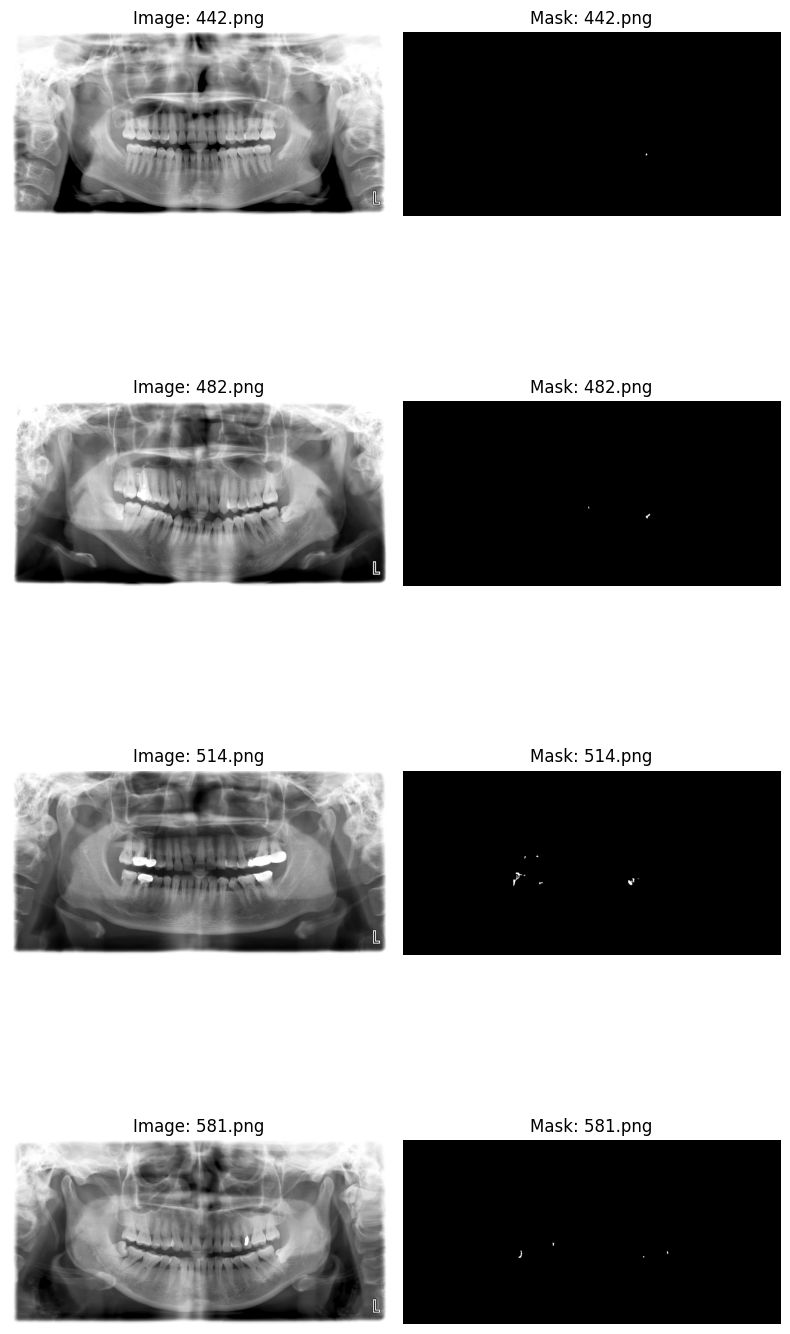

In [20]:
import random

def show_random_examples(n=4, images_dir=TRAIN_IMG_DIR, masks_dir=TRAIN_MASK_DIR, file_list=None):
    if file_list is None:
        file_list = list_files(images_dir)
    sample_files = random.sample(file_list, min(n, len(file_list)))

    plt.figure(figsize=(8, 4 * len(sample_files)))

    for i, fname in enumerate(sample_files):
        img_path = images_dir / fname
        mask_path = masks_dir / fname

        img = np.array(Image.open(img_path).convert("L"))
        mask = np.array(Image.open(mask_path).convert("L"))

        # X-ray
        plt.subplot(len(sample_files), 2, 2*i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Image: {fname}")
        plt.axis("off")

        # Mask
        plt.subplot(len(sample_files), 2, 2*i + 2)
        plt.imshow(mask, cmap="gray")
        plt.title(f"Mask: {fname}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_examples(n=4, images_dir=TRAIN_IMG_DIR, masks_dir=TRAIN_MASK_DIR, file_list=train_imgs)
